# ECG Heartbeat Classification — Models
**Author:** Abdullah Al Noman Taki — VR528988
**University of Verona**


In [1]:
# ── 1. Imports ───────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import gc

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, LSTM, GRU, Dense,
    Dropout, Flatten, Bidirectional, Add,
    MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

print('TF version:', tf.__version__)
print('GPU:', len(tf.config.list_physical_devices('GPU')) > 0)

TF version: 2.20.0
GPU: False


In [2]:
# ── 2. Load Data from Google Drive ───────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

X_train = np.load('/content/drive/MyDrive/ECG/X_train_seq.npy')
X_val   = np.load('/content/drive/MyDrive/ECG/X_val_seq.npy')
X_test  = np.load('/content/drive/MyDrive/ECG/X_test_seq.npy')
y_train = np.load('/content/drive/MyDrive/ECG/y_train.npy')
y_val   = np.load('/content/drive/MyDrive/ECG/y_val.npy')
y_test  = np.load('/content/drive/MyDrive/ECG/y_test.npy')

y_train_cat = to_categorical(y_train, 5)
y_val_cat   = to_categorical(y_val,   5)
y_test_cat  = to_categorical(y_test,  5)

CLASS_NAMES = ['Normal', 'Supraventricular', 'Ventricular', 'Fusion', 'Unknown']

print('X_train:', X_train.shape)
print('X_val  :', X_val.shape)
print('X_test :', X_test.shape)

Mounted at /content/drive
X_train: (12750, 187, 1)
X_val  : (2250, 187, 1)
X_test : (1500, 187, 1)


In [3]:
# ── 3. Shared Config ─────────────────────────────────────────────────────────
INPUT_SHAPE = (187, 1)
N_CLASSES   = 5
EPOCHS      = 20
BATCH_SIZE  = 64
LR          = 0.001

all_histories = {}
all_reports   = {}
all_cms       = {}

In [4]:
# ── 4. Train & Evaluate Function ─────────────────────────────────────────────
def train_and_evaluate(name, model):
    print(f'\n{"="*50}\n  Training: {name}\n{"="*50}')
    model.summary()

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
    ]

    model.compile(
        optimizer=tf.keras.optimizers.Adam(LR),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train, y_train_cat,
        validation_data=(X_val, y_val_cat),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1
    )

    y_pred     = model.predict(X_test)
    y_pred_cls = np.argmax(y_pred, axis=1)

    report = classification_report(y_test, y_pred_cls,
                                    target_names=CLASS_NAMES, output_dict=True)
    cm = confusion_matrix(y_test, y_pred_cls)

    all_histories[name] = history
    all_reports[name]   = report
    all_cms[name]       = cm

    print(f'\nTest Accuracy: {report["accuracy"]:.4f}')
    print(classification_report(y_test, y_pred_cls, target_names=CLASS_NAMES))
    return model, history

In [5]:
# ── MODEL 1: 1D CNN (Baseline) ───────────────────────────────────────────────
tf.keras.backend.clear_session(); gc.collect()

def build_cnn():
    inp = Input(shape=INPUT_SHAPE)
    x = Conv1D(32, 5, activation='relu', padding='same')(inp)
    x = MaxPooling1D(2)(x)
    x = Conv1D(64, 5, activation='relu', padding='same')(x)
    x = MaxPooling1D(2)(x)
    x = Conv1D(128, 3, activation='relu', padding='same')(x)
    x = MaxPooling1D(2)(x)
    x = Flatten()(x)
    x = Dropout(0.3)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.2)(x)
    out = Dense(N_CLASSES, activation='softmax')(x)
    return Model(inp, out, name='1D_CNN')

cnn_model, cnn_history = train_and_evaluate('1D CNN', build_cnn())


  Training: 1D CNN


Model: "1D_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 187, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 187, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 93, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 93, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 46, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 46, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 23, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2944)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2944)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       376,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 412,805 (1.57 MB)

 Trainable params: 412,805 (1.57 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 14s 61ms/step - accuracy: 0.7445 - loss: 0.6903 - val_accuracy: 0.8507 - val_loss: 0.4255 - learning_rate: 0.0010
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step - accuracy: 0.8562 - loss: 0.3892 - val_accuracy: 0.8893 - val_loss: 0.3343 - learning_rate: 0.0010
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 11s 55ms/step - accuracy: 0.8853 - loss: 0.3088 - val_accuracy: 0.9004 - val_loss: 0.2803 - learning_rate: 0.0010
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 11s 54ms/step - accuracy: 0.9036 - loss: 0.2659 - val_accuracy: 0.9182 - val_loss: 0.2414 - learning_rate: 0.0010
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - accuracy: 0.9205 - loss: 0.2189 - val_accuracy: 0.9280 - val_loss: 0.2145 - learning_rate: 0.0010
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 11s 53ms/step - accuracy: 0.9287 - loss: 0.1942 - val_accuracy: 0.9409 - val_loss: 0.1769 - learning_rate: 0.0010
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - accuracy: 0.9395 - los

In [6]:
# ── MODEL 2: Residual CNN ─────────────────────────────────────────────────────
tf.keras.backend.clear_session(); gc.collect()

def residual_block(x, filters):
    shortcut = Conv1D(filters, 1, padding='same')(x)
    x = Conv1D(filters, 3, padding='same', activation='relu')(x)
    x = Conv1D(filters, 3, padding='same')(x)
    x = Add()([x, shortcut])
    return tf.keras.layers.Activation('relu')(x)

def build_residual_cnn():
    inp = Input(shape=INPUT_SHAPE)
    x = Conv1D(32, 5, activation='relu', padding='same')(inp)
    x = MaxPooling1D(2)(x)
    x = residual_block(x, 64)
    x = MaxPooling1D(2)(x)
    x = residual_block(x, 128)
    x = MaxPooling1D(2)(x)
    x = GlobalAveragePooling1D()(x)
    x = Dropout(0.3)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.2)(x)
    out = Dense(N_CLASSES, activation='softmax')(x)
    return Model(inp, out, name='Residual_CNN')

res_model, res_history = train_and_evaluate('Residual CNN', build_residual_cnn())


  Training: Residual CNN


Model: "Residual_CNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 187, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 187, 32)   │        192 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 93, 32)    │          0 │ conv1d[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 93, 64)    │      6,208 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 93, 64)    │     12,352 │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 93, 64)    │      2,112 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 93, 64)    │          0 │ conv1d_3[0][0],   │
│                     │                   │            │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 93, 64)    │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 46, 64)    │          0 │ activation[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 46, 128)   │     24,704 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 46, 128)   │     49,280 │ conv1d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 46, 128)   │      8,320 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 46, 128)   │          0 │ conv1d_6[0][0],   │
│                     │                   │            │ conv1d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 46, 128)   │          0 │ add_1[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 23, 128)   │          0 │ activation_1[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ max_pooling1d_2[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     16,512 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 5)         │        645 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴─────────────────

 Total params: 120,325 (470.02 KB)

 Trainable params: 120,325 (470.02 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 20s 87ms/step - accuracy: 0.4626 - loss: 1.2152 - val_accuracy: 0.6018 - val_loss: 0.9102 - learning_rate: 0.0010
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 17s 85ms/step - accuracy: 0.6623 - loss: 0.8486 - val_accuracy: 0.7813 - val_loss: 0.6721 - learning_rate: 0.0010
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 20s 85ms/step - accuracy: 0.7642 - loss: 0.6367 - val_accuracy: 0.7964 - val_loss: 0.5683 - learning_rate: 0.0010
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 20s 85ms/step - accuracy: 0.8029 - loss: 0.5460 - val_accuracy: 0.8280 - val_loss: 0.4685 - learning_rate: 0.0010
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 21s 86ms/step - accuracy: 0.8245 - loss: 0.4926 - val_accuracy: 0.8471 - val_loss: 0.4184 - learning_rate: 0.0010
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 20s 82ms/step - accuracy: 0.8362 - loss: 0.4487 - val_accuracy: 0.8533 - val_loss: 0.3898 - learning_rate: 0.0010
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 17s 85ms/step - accuracy: 0.8472 - l

In [8]:
# ── MODEL 3: GRU ─────────────────────────────────────────────────────────────
tf.keras.backend.clear_session(); gc.collect()

def build_gru():
    inp = Input(shape=INPUT_SHAPE)
    x = Conv1D(32, 5, activation='relu', padding='same')(inp)
    x = MaxPooling1D(2)(x)
    x = Conv1D(64, 3, activation='relu', padding='same')(x)
    x = MaxPooling1D(2)(x)
    x = GRU(64)(x)
    x = Dropout(0.3)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.2)(x)
    out = Dense(N_CLASSES, activation='softmax')(x)
    return Model(inp, out, name='GRU')

gru_model, gru_history = train_and_evaluate('GRU', build_gru())


  Training: GRU


Model: "GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 187, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 187, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 93, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 93, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 46, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,325 (157.52 KB)

 Trainable params: 40,325 (157.52 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 18s 68ms/step - accuracy: 0.4054 - loss: 1.3786 - val_accuracy: 0.4991 - val_loss: 1.2049 - learning_rate: 0.0010
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 13s 66ms/step - accuracy: 0.5059 - loss: 1.1964 - val_accuracy: 0.5453 - val_loss: 1.1586 - learning_rate: 0.0010
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 13s 67ms/step - accuracy: 0.5344 - loss: 1.1508 - val_accuracy: 0.5520 - val_loss: 1.1351 - learning_rate: 0.0010
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 13s 66ms/step - accuracy: 0.5532 - loss: 1.1217 - val_accuracy: 0.5253 - val_loss: 1.1561 - learning_rate: 0.0010
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 12s 60ms/step - accuracy: 0.5646 - loss: 1.0732 - val_accuracy: 0.5844 - val_loss: 1.0115 - learning_rate: 0.0010
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 12s 62ms/step - accuracy: 0.6387 - loss: 0.9142 - val_accuracy: 0.6760 - val_loss: 0.7772 - learning_rate: 0.0010
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 22s 69ms/step - accuracy: 0.6995 - l

In [9]:
# ── MODEL 4: CNN + LSTM (Hybrid) ─────────────────────────────────────────────
tf.keras.backend.clear_session(); gc.collect()

def build_cnn_lstm():
    inp = Input(shape=INPUT_SHAPE)
    x = Conv1D(32, 5, activation='relu', padding='same')(inp)
    x = MaxPooling1D(2)(x)
    x = Conv1D(64, 3, activation='relu', padding='same')(x)
    x = MaxPooling1D(2)(x)
    x = Conv1D(128, 3, activation='relu', padding='same')(x)
    x = MaxPooling1D(2)(x)
    x = LSTM(64)(x)
    x = Dropout(0.3)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.2)(x)
    out = Dense(N_CLASSES, activation='softmax')(x)
    return Model(inp, out, name='CNN_LSTM')

cnn_lstm_model, cnn_lstm_history = train_and_evaluate('CNN + LSTM', build_cnn_lstm())


  Training: CNN + LSTM


Model: "CNN_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 187, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 187, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 93, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 93, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 46, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 46, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 23, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89,477 (349.52 KB)

 Trainable params: 89,477 (349.52 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 17s 70ms/step - accuracy: 0.4828 - loss: 1.2312 - val_accuracy: 0.6400 - val_loss: 0.9269 - learning_rate: 0.0010
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 20s 68ms/step - accuracy: 0.6958 - loss: 0.8089 - val_accuracy: 0.7409 - val_loss: 0.7122 - learning_rate: 0.0010
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 13s 63ms/step - accuracy: 0.7290 - loss: 0.7211 - val_accuracy: 0.7640 - val_loss: 0.6299 - learning_rate: 0.0010
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 13s 65ms/step - accuracy: 0.7737 - loss: 0.6084 - val_accuracy: 0.7569 - val_loss: 0.6607 - learning_rate: 0.0010
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 13s 65ms/step - accuracy: 0.7995 - loss: 0.5521 - val_accuracy: 0.8129 - val_loss: 0.4871 - learning_rate: 0.0010
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 14s 68ms/step - accuracy: 0.8229 - loss: 0.4944 - val_accuracy: 0.8413 - val_loss: 0.4357 - learning_rate: 0.0010
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 14s 70ms/step - accuracy: 0.8391 - l

In [10]:
# ── MODEL 5: Transformer ─────────────────────────────────────────────────────
tf.keras.backend.clear_session(); gc.collect()

def transformer_block(x, num_heads, ff_dim, dropout=0.1):
    attn = MultiHeadAttention(num_heads=num_heads, key_dim=x.shape[-1])(x, x)
    x = LayerNormalization(epsilon=1e-6)(x + attn)
    ff = Dense(ff_dim, activation='relu')(x)
    ff = Dropout(dropout)(ff)
    ff = Dense(x.shape[-1])(ff)
    return LayerNormalization(epsilon=1e-6)(x + ff)

def build_transformer():
    inp = Input(shape=INPUT_SHAPE)

    x = Conv1D(32, 5, activation='relu', padding='same')(inp)
    x = MaxPooling1D(2)(x)
    x = Conv1D(64, 3, activation='relu', padding='same')(x)
    x = MaxPooling1D(2)(x)
    # Transformer blocks
    x = Dense(32)(x)
    x = transformer_block(x, num_heads=2, ff_dim=64)
    x = transformer_block(x, num_heads=2, ff_dim=64)
    x = GlobalAveragePooling1D()(x)
    x = Dropout(0.3)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.2)(x)
    out = Dense(N_CLASSES, activation='softmax')(x)
    return Model(inp, out, name='Transformer')

trans_model, trans_history = train_and_evaluate('Transformer', build_transformer())


  Training: Transformer


Model: "Transformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 187, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 187, 32)   │        192 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 93, 32)    │          0 │ conv1d[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 93, 64)    │      6,208 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 46, 64)    │          0 │ conv1d_1[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 46, 32)    │      2,080 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 46, 32)    │      8,416 │ dense[0][0],      │
│ (MultiHeadAttentio… │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 46, 32)    │          0 │ dense[0][0],      │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 46, 32)    │         64 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 46, 64)    │      2,112 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 46, 64)    │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 46, 32)    │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 46, 32)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 46, 32)    │         64 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 46, 32)    │      8,416 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 46, 32)    │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 46, 32)    │         64 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 46, 64)    │      2,112 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 46, 64)    │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 36,389 (142.14 KB)

 Trainable params: 36,389 (142.14 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 34s 133ms/step - accuracy: 0.3963 - loss: 1.3737 - val_accuracy: 0.6227 - val_loss: 0.9215 - learning_rate: 0.0010
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 26s 129ms/step - accuracy: 0.6654 - loss: 0.8486 - val_accuracy: 0.7418 - val_loss: 0.7005 - learning_rate: 0.0010
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 24s 118ms/step - accuracy: 0.7591 - loss: 0.6648 - val_accuracy: 0.7876 - val_loss: 0.5550 - learning_rate: 0.0010
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 26s 132ms/step - accuracy: 0.7905 - loss: 0.5838 - val_accuracy: 0.8289 - val_loss: 0.4792 - learning_rate: 0.0010
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 41s 130ms/step - accuracy: 0.8154 - loss: 0.5354 - val_accuracy: 0.7947 - val_loss: 0.5481 - learning_rate: 0.0010
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 25s 126ms/step - accuracy: 0.8320 - loss: 0.4801 - val_accuracy: 0.8347 - val_loss: 0.4380 - learning_rate: 0.0010
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 40s 121ms/step - accuracy: 0.8

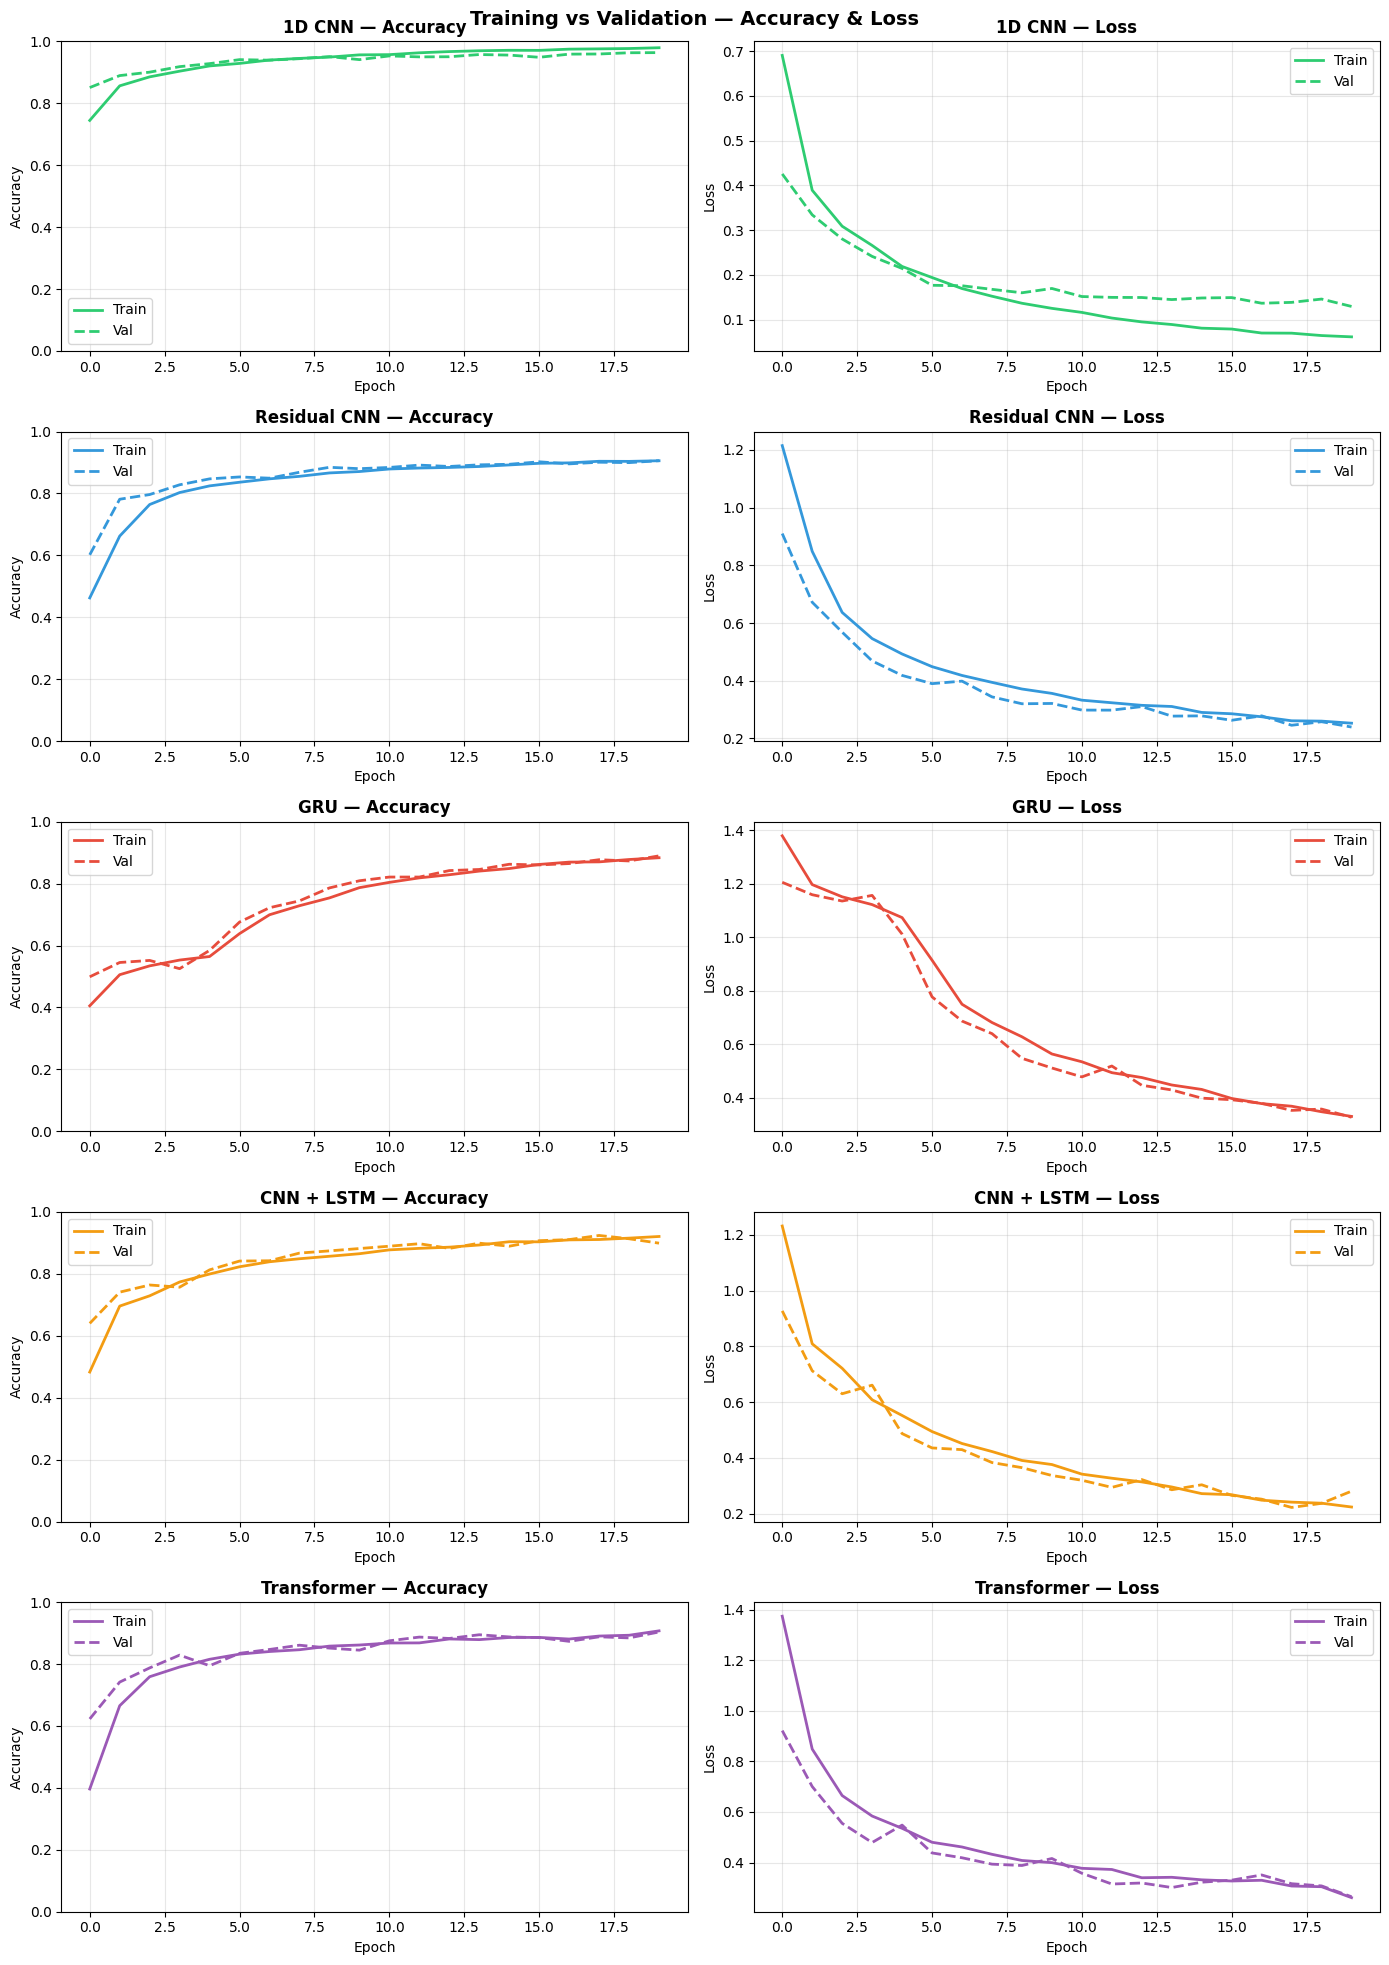

In [11]:
# ── Results: Training Curves ──────────────────────────────────────────────────
fig, axes = plt.subplots(5, 2, figsize=(14, 20))
colors = ['#2ecc71','#3498db','#e74c3c','#f39c12','#9b59b6']

for i, (name, history) in enumerate(all_histories.items()):
    # Accuracy
    axes[i][0].plot(history.history['accuracy'],     color=colors[i], linewidth=2, label='Train')
    axes[i][0].plot(history.history['val_accuracy'], color=colors[i], linewidth=2,
                    linestyle='--', label='Val')
    axes[i][0].set_title(f'{name} — Accuracy', fontweight='bold')
    axes[i][0].set_xlabel('Epoch')
    axes[i][0].set_ylabel('Accuracy')
    axes[i][0].legend()
    axes[i][0].grid(True, alpha=0.3)
    axes[i][0].set_ylim([0, 1])

    # Loss
    axes[i][1].plot(history.history['loss'],     color=colors[i], linewidth=2, label='Train')
    axes[i][1].plot(history.history['val_loss'], color=colors[i], linewidth=2,
                    linestyle='--', label='Val')
    axes[i][1].set_title(f'{name} — Loss', fontweight='bold')
    axes[i][1].set_xlabel('Epoch')
    axes[i][1].set_ylabel('Loss')
    axes[i][1].legend()
    axes[i][1].grid(True, alpha=0.3)

plt.suptitle('Training vs Validation — Accuracy & Loss', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

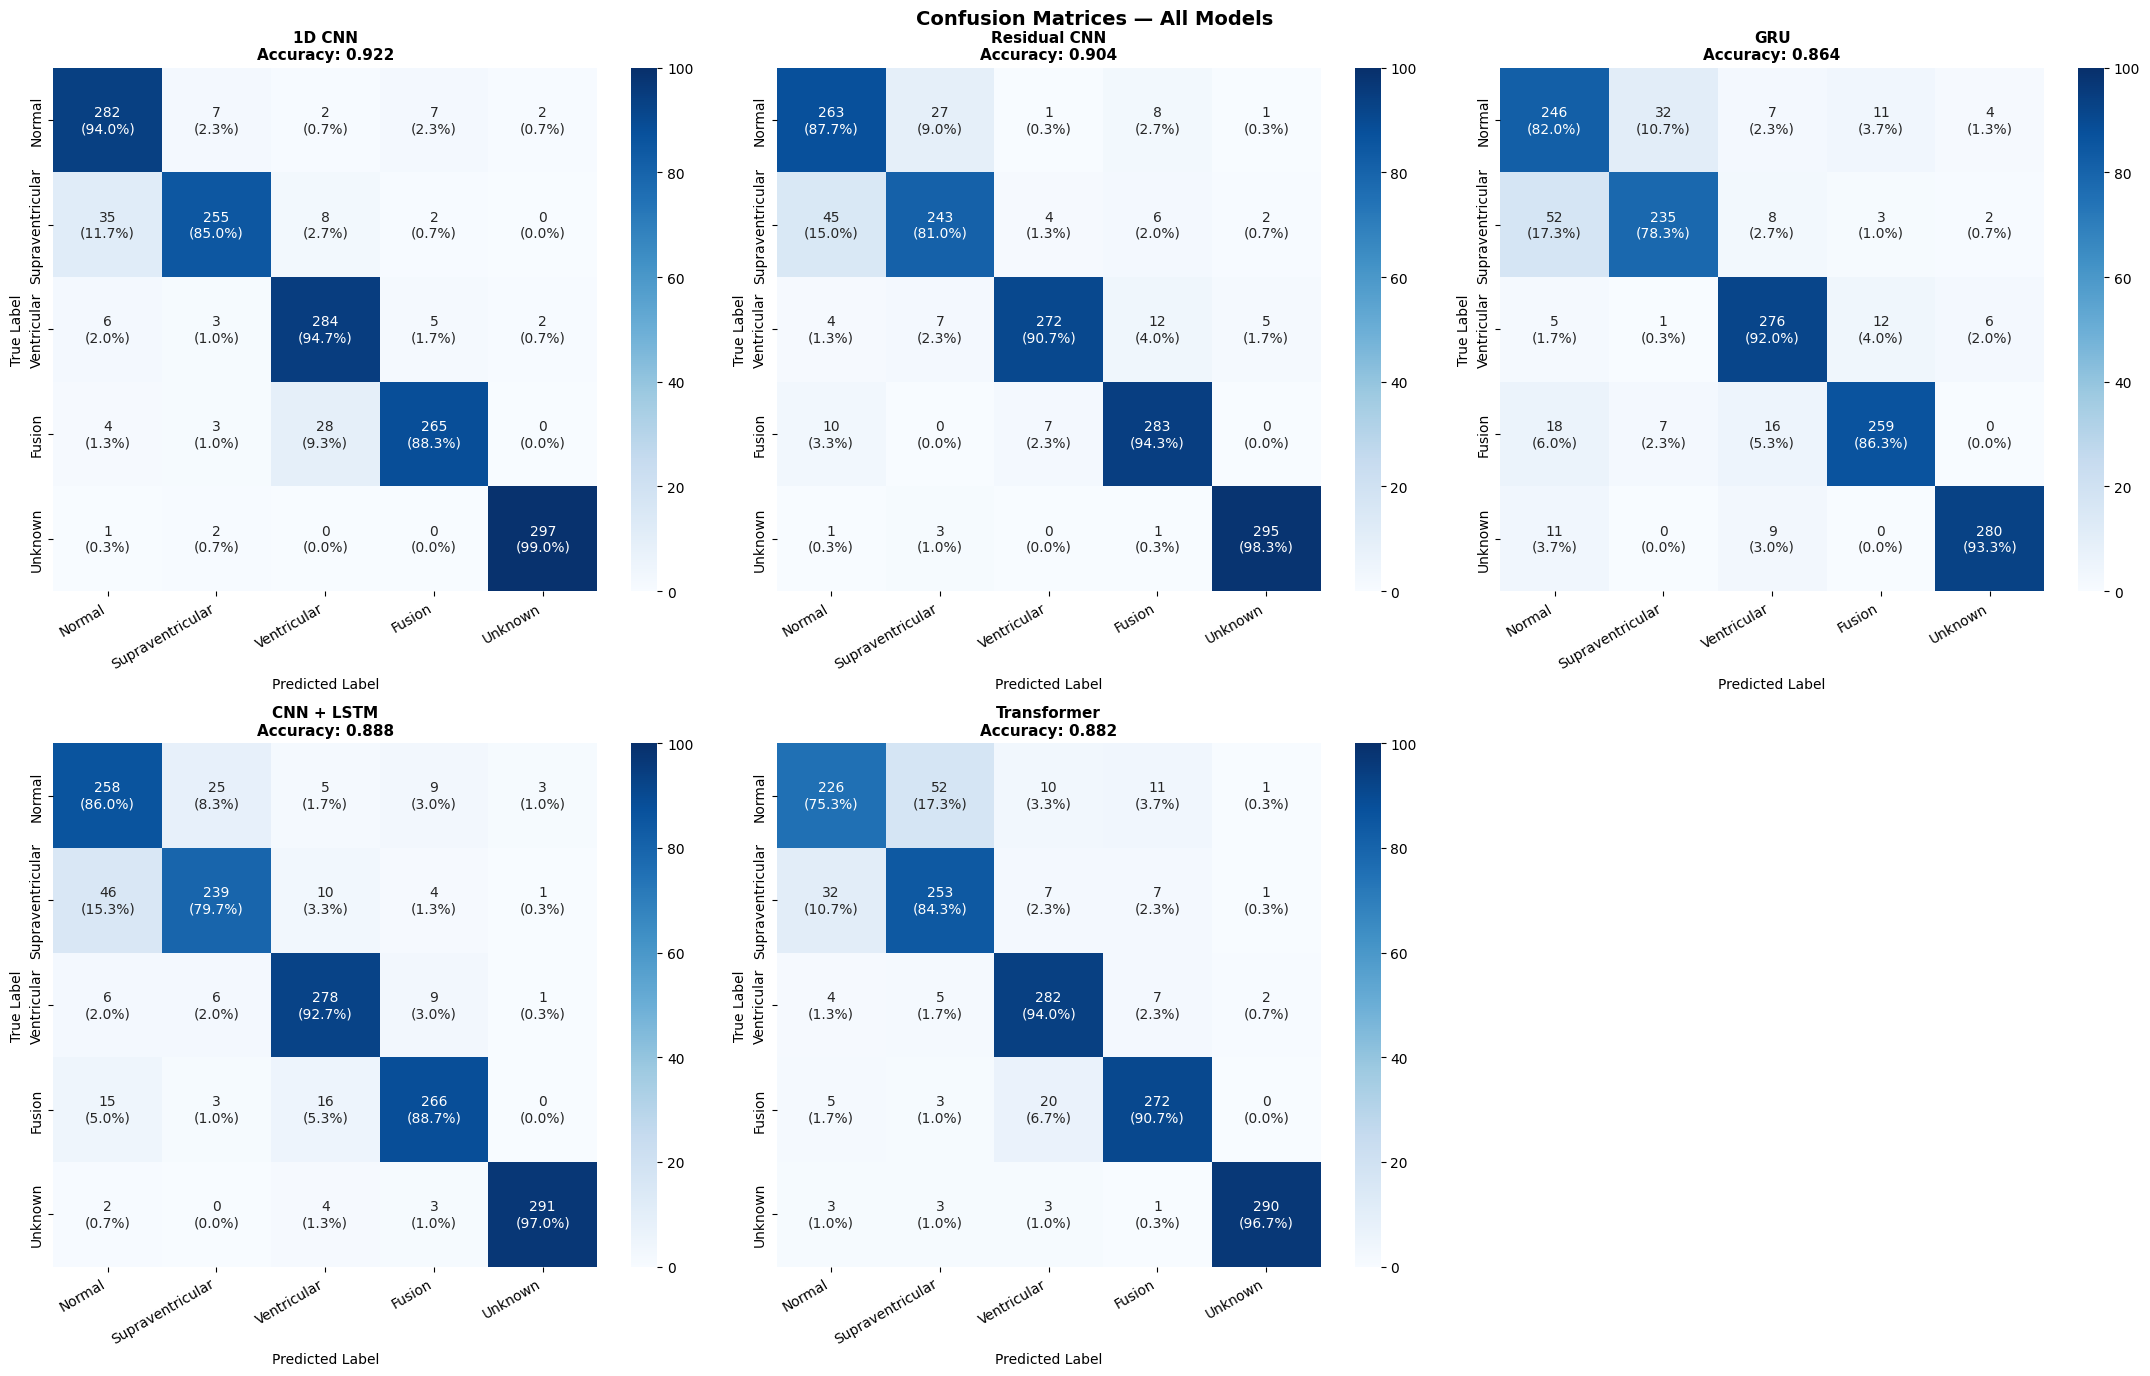

In [12]:
# ── Results: Confusion Matrices ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(22, 14))
axes = axes.flatten()

for i, (name, cm) in enumerate(all_cms.items()):
    # Percentage calculate করো
    cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    # Count + percentage একসাথে দেখাও
    labels = np.array([[f'{count}\n({pct:.1f}%)'
                        for count, pct in zip(row_c, row_p)]
                       for row_c, row_p in zip(cm, cm_pct)])

    sns.heatmap(cm_pct, annot=labels, fmt='', cmap='Blues',
                xticklabels=CLASS_NAMES,
                yticklabels=CLASS_NAMES,
                ax=axes[i], vmin=0, vmax=100)

    axes[i].set_title(f'{name}\nAccuracy: {all_reports[name]["accuracy"]:.3f}',
                      fontweight='bold', fontsize=11)
    axes[i].set_ylabel('True Label')
    axes[i].set_xlabel('Predicted Label')
    plt.setp(axes[i].get_xticklabels(), rotation=30, ha='right')

axes[5].set_visible(False)
plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

=== Final Results ===
       Model  Accuracy  Macro F1  Macro Prec  Macro Recall
      1D CNN     0.922    0.9219      0.9245         0.922
Residual CNN     0.904    0.9040      0.9053         0.904
  CNN + LSTM     0.888    0.8882      0.8900         0.888
 Transformer     0.882    0.8815      0.8825         0.882
         GRU     0.864    0.8647      0.8673         0.864

🏆 Best Model: 1D CNN (Accuracy=0.922)


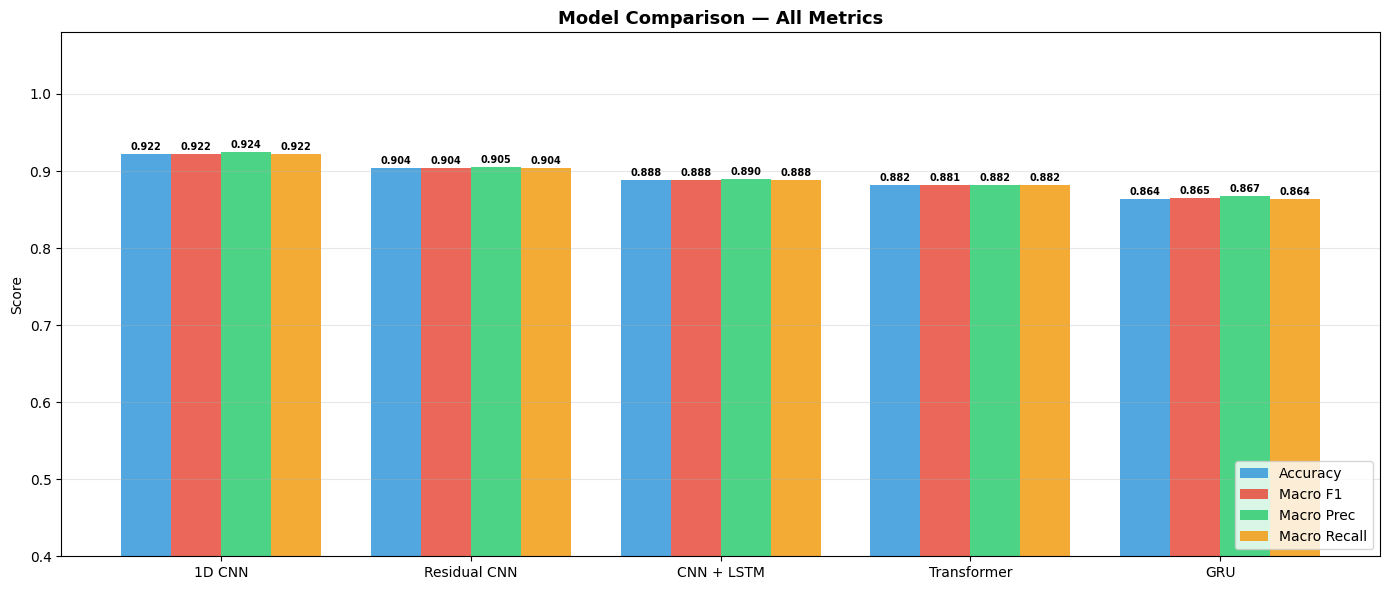

In [13]:
# ── Results: Comparison Table & Bar Chart ─────────────────────────────────────
import pandas as pd

results = []
for name, report in all_reports.items():
    results.append({
        'Model'        : name,
        'Accuracy'     : round(report['accuracy'], 4),
        'Macro F1'     : round(report['macro avg']['f1-score'], 4),
        'Macro Prec'   : round(report['macro avg']['precision'], 4),
        'Macro Recall' : round(report['macro avg']['recall'], 4),
    })

df = pd.DataFrame(results).sort_values('Accuracy', ascending=False).reset_index(drop=True)

print('=== Final Results ===')
print(df.to_string(index=False))
print(f'\n🏆 Best Model: {df.iloc[0]["Model"]} (Accuracy={df.iloc[0]["Accuracy"]})')

# ── Bar Chart — 4 metrics একসাথে ─────────────────────────────────────────────
x      = np.arange(len(df))
width  = 0.2
colors = ['#3498db','#e74c3c','#2ecc71','#f39c12']
metrics = ['Accuracy', 'Macro F1', 'Macro Prec', 'Macro Recall']

fig, ax = plt.subplots(figsize=(14, 6))

for j, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + (j - 1.5) * width, df[metric], width,
                  label=metric, color=color, alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{bar.get_height():.3f}',
                ha='center', fontsize=7, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(df['Model'])
ax.set_ylim([0.4, 1.08])
ax.set_ylabel('Score')
ax.set_title('Model Comparison — All Metrics', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

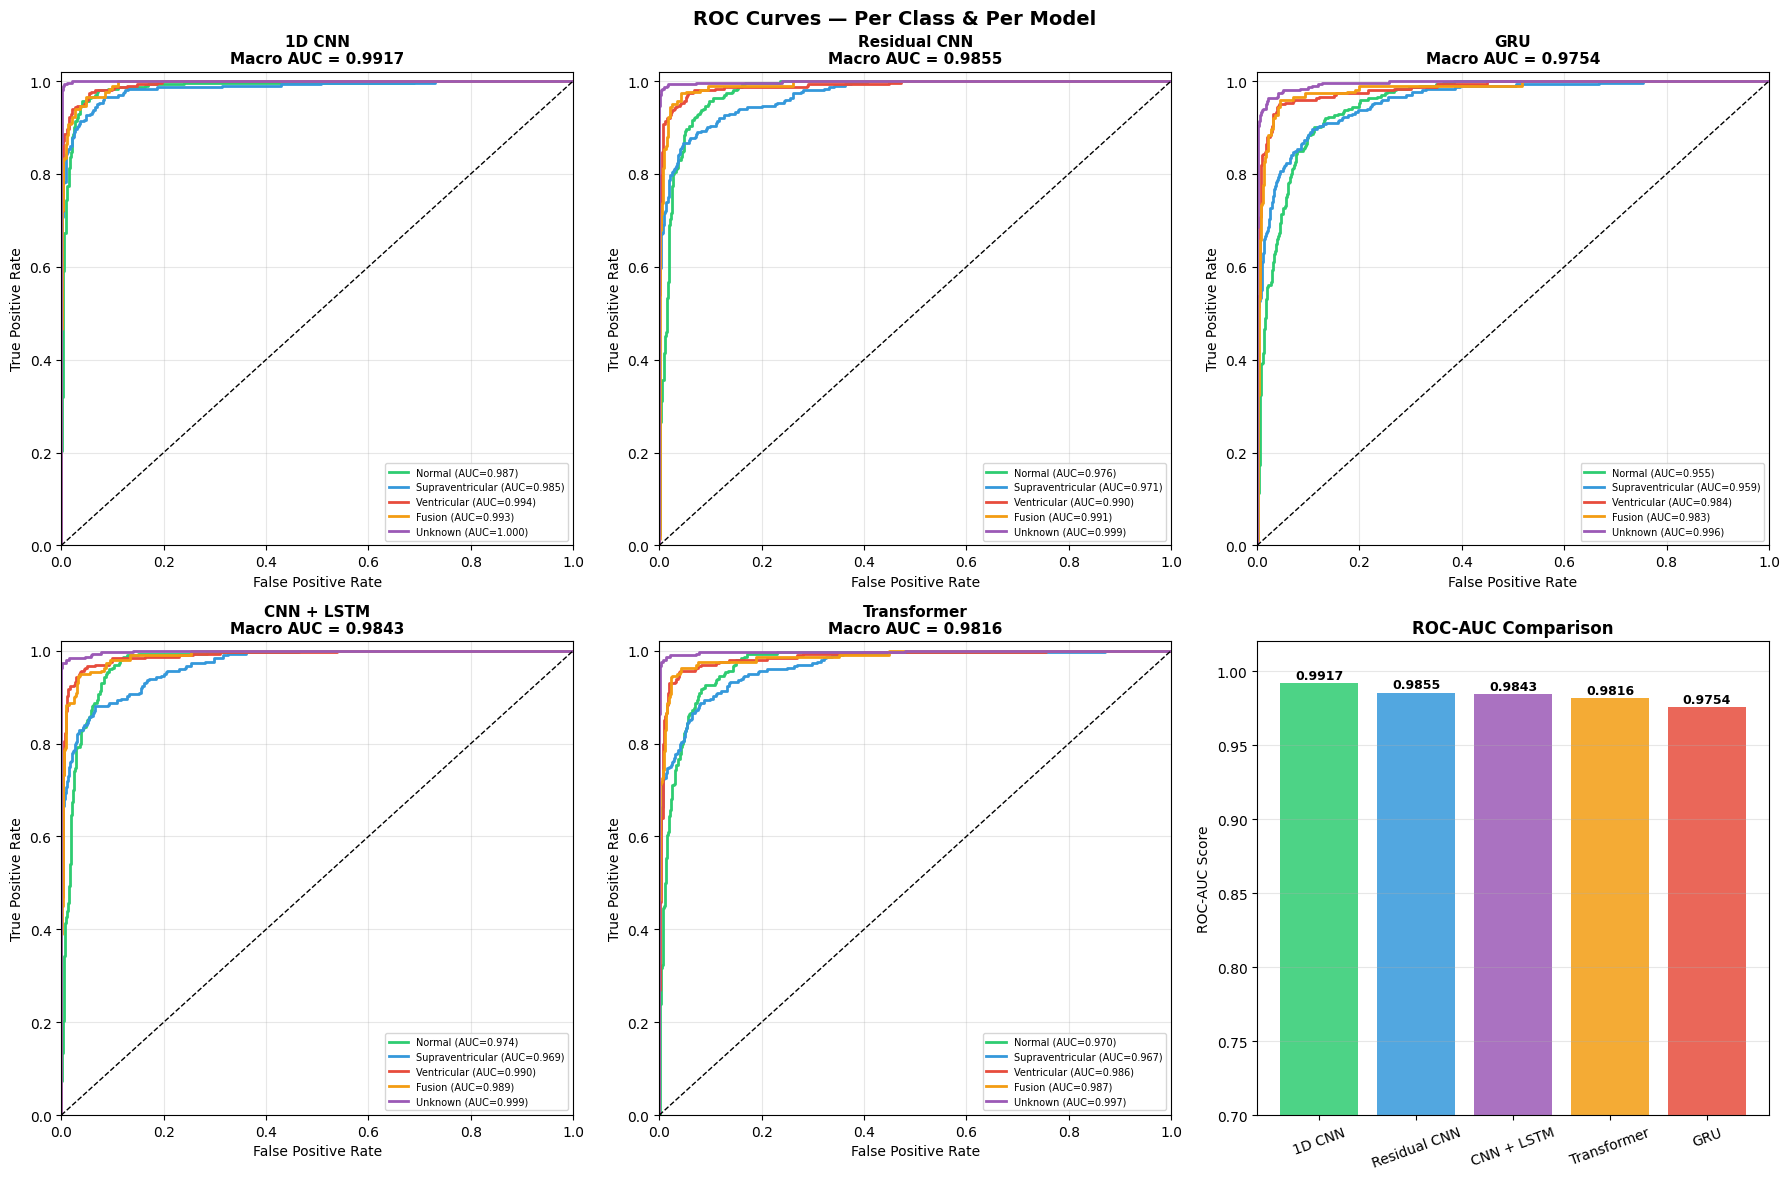


=== ROC-AUC Results ===
       Model  ROC-AUC
      1D CNN   0.9917
Residual CNN   0.9855
  CNN + LSTM   0.9843
 Transformer   0.9816
         GRU   0.9754

🏆 Best Model: 1D CNN (AUC=0.9917)


In [14]:
# ── ROC Curves & AUC ─────────────────────────────────────────────────────────
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize

CLASS_NAMES = ['Normal', 'Supraventricular', 'Ventricular', 'Fusion', 'Unknown']
colors_cls  = ['#2ecc71','#3498db','#e74c3c','#f39c12','#9b59b6']

models = {
    "1D CNN"       : cnn_model,
    "Residual CNN" : res_model,
    "GRU"          : gru_model,
    "CNN + LSTM"   : cnn_lstm_model,
    "Transformer"  : trans_model
}

n_classes  = 5
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

auc_results = []

for i, (name, model) in enumerate(models.items()):
    y_prob    = model.predict(X_test, verbose=0)  # একবার predict
    macro_auc = roc_auc_score(y_test_bin, y_prob,
                               multi_class='ovr', average='macro')
    auc_results.append({'Model': name, 'ROC-AUC': round(macro_auc, 4)})

    ax = axes[i]

    # প্রতিটা class এর আলাদা ROC curve
    for cls, (cls_name, color) in enumerate(zip(CLASS_NAMES, colors_cls)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, cls], y_prob[:, cls])
        cls_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, linewidth=2,
                label=f"{cls_name} (AUC={cls_auc:.3f})")

    ax.plot([0,1],[0,1],'k--', linewidth=1)
    ax.set_title(f'{name}\nMacro AUC = {macro_auc:.4f}',
                 fontweight='bold', fontsize=11)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right', fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])

# 6th subplot — AUC comparison bar chart
ax = axes[5]
auc_df = pd.DataFrame(auc_results).sort_values('ROC-AUC', ascending=False)
bar_colors = ['#2ecc71','#3498db','#9b59b6','#f39c12','#e74c3c']
bars = ax.bar(auc_df['Model'], auc_df['ROC-AUC'], color=bar_colors, alpha=0.85)
ax.set_title('ROC-AUC Comparison', fontweight='bold')
ax.set_ylabel('ROC-AUC Score')
ax.set_ylim([0.7, 1.02])
ax.tick_params(axis='x', rotation=20)
ax.grid(True, alpha=0.3, axis='y')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.003,
            f'{bar.get_height():.4f}',
            ha='center', fontsize=9, fontweight='bold')

plt.suptitle('ROC Curves — Per Class & Per Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== ROC-AUC Results ===')
print(auc_df.to_string(index=False))
print(f'\n🏆 Best Model: {auc_df.iloc[0]["Model"]} (AUC={auc_df.iloc[0]["ROC-AUC"]})')